# Project Title

# Spotify Artists Streaming Analysis Using Python

## Objective

Analyze Spotify artists' streaming performance and answer business questions using Python libraries.

## Libraries Used

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## Load Dataset

In [54]:
df = pd.read_csv("E:/spotify_artists.csv")

## Explore Dataset

In [55]:
# First 5 Rows
df.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [56]:
# Last 5 Rows
df.tail()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
495,The Cure,Male,United Kingdom,English,Rock,Group,1979,7034.1,7035.0,3.3,6940.1,98.663653,94.0,1.336347
496,The MarÃ­as,Mixed,United States,English,Pop,Group,2017,7029.1,5774.4,1261.4,5705.9,81.175399,1323.2,18.824601
497,Limp Bizkit,Male,United States,English,Nu Metal,Group,1997,7018.9,7018.4,5.4,6806.0,96.966761,212.9,3.033239
498,Korn,Male,United States,English,Metal,Group,1994,6976.4,4188.4,2798.5,6414.9,91.951436,561.5,8.048564
499,Omar Courtz,Male,United States,Spanish,Reggaeton,Solo,2017,6972.0,6956.0,20.3,1876.2,26.910499,5095.8,73.089501


In [57]:
# Shape
df.shape

(500, 14)

In [58]:
# Columns
df.columns

Index(['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', ' Artist Type', 'Debut Year',
       'Total Streams (in millions)', 'Lead Streams (in millions)',
       'Feature Streams (in millions)', 'Solo Streams (in millions)',
       '% of Solo Streams', 'Collaborative Streams (in millions)',
       '% of Collaborative Streams'],
      dtype='str')

In [59]:
# Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    str    
 1   Sex                                  500 non-null    str    
 2   Country of Origin                    500 non-null    str    
 3   Primary Language                     500 non-null    str    
 4   Primary Genre                        500 non-null    str    
 5    Artist Type                         500 non-null    str    
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams                    500 no

In [60]:
# Statistical Summary
df.describe()

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2005.346000,16817.610200,12141.734000,4681.289000,8324.397600,50.613084,8493.212600,49.386916
std,13.312578,14845.197632,11844.675186,5952.827762,9589.010168,33.762147,9612.491536,33.762147
min,1939.000000,6972.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2001.750000,8768.175000,6489.750000,696.500000,2519.775000,20.117951,2015.650000,16.860219
50%,2009.000000,11923.250000,8716.350000,3005.600000,6472.950000,47.062829,6592.250000,52.937171
75%,2014.000000,18020.050000,13456.900000,6093.350000,10115.550000,83.139781,11019.575000,79.882049
max,2023.000000,137492.100000,126177.300000,43710.500000,113421.500000,100.000000,84168.200000,100.000000


## Data Cleaning

In [61]:
# Check Missing Values
df.isnull().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [62]:
# Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [63]:
# Remove Duplicates
df = df.drop_duplicates()

In [64]:
# Rename Columns
df.columns = df.columns.str.strip()

## Feature Engineering

In [65]:
# Artist Career Length
current_year = 2026
df["Career_Years"] = current_year - df["Debut Year"]

In [66]:
# Stream Difference
df["Lead_Feature_Difference"] = (
    df["Lead Streams (in millions)"] -
    df["Feature Streams (in millions)"]
)

In [67]:
# Collaboration Ratio
df["Collaboration_Ratio"] = (
    df["Collaborative Streams (in millions)"] /
    df["Total Streams (in millions)"]
)

In [68]:
# Solo Ratio
df["Solo_Ratio"] = (
    df["Solo Streams (in millions)"] /
    df["Total Streams (in millions)"]
)

## NumPy Analysis

In [69]:
# Average Total Streams
np.mean(df["Total Streams (in millions)"])

np.float64(16817.6102)

In [70]:
# Maximum Streams
np.max(df["Total Streams (in millions)"])

np.float64(137492.1)

In [71]:
# Minimum Streams
np.min(df["Total Streams (in millions)"])

np.float64(6972.0)

In [72]:
# Standard Deviation
np.std(df["Total Streams (in millions)"])

np.float64(14830.345004096027)

In [73]:
# Median
np.median(df["Total Streams (in millions)"])

np.float64(11923.25)

## Business Questions

In [74]:
# 1. Top 10 Most Streamed Artists
df.sort_values(
    by="Total Streams (in millions)",
    ascending=False
)[["Artist Name","Total Streams (in millions)"]]

,Artist Name,Total Streams (in millions)
0,Drake,137492.1
1,Taylor Swift,127861.0
2,Bad Bunny,125899.8
3,The Weeknd,95703.2
4,Justin Bieber,78104.4
...,...,...
495,The Cure,7034.1
496,The MarÃ­as,7029.1
497,Limp Bizkit,7018.9
498,Korn,6976.4


In [75]:
# 2. Male vs Female Artists
df["Sex"].value_counts()

Sex
Male      390
Female     88
Mixed      22
Name: count, dtype: int64

In [76]:
# 3. Artists by Country
df["Country of Origin"].value_counts()

Country of Origin
United States          265
United Kingdom          55
Mexico                  27
Canada                  18
Colombia                16
Brazil                  15
India                   13
South Korea             11
Argentina                9
Australia                7
Germany                  7
Spain                    6
France                   5
Sweden                   5
Ireland                  4
Italy                    3
Scotland                 2
Norway                   2
Netherlands              2
Jamaica                  2
Japan                    2
Nigeria                  2
Dominican Republic       2
Barbados                 1
Trinidad and Tobago      1
Cuba                     1
Panama                   1
Senegal                  1
New Zealand              1
Morocco                  1
Chile                    1
Russia                   1
South Africa             1
Venezuela                1
Belgium                  1
DR Congo                 1
Nepal     

In [77]:
# 4. Most Common Genre
df["Primary Genre"].value_counts()

Primary Genre
Hip-Hop             115
Pop                 102
Rock                 60
Reggaeton            43
R&B                  31
Latin                30
EDM                  22
Regional Mexican     19
K-Pop                11
Filmi                11
Country              10
Alternative           9
Sertanjeo             9
Metal                 8
Folk                  4
Soundtrack            3
Bachata               3
Soul                  3
Reggae                2
Afrobeats             2
Spoken Word           1
Children's Music      1
Nu Metal              1
Name: count, dtype: int64

In [78]:
# 5. English vs Spanish Artists
df["Primary Language"].value_counts()

Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
German          7
French          4
Italian         3
Tamil           2
Urdu            1
Punjabi         1
Name: count, dtype: int64

In [79]:
# 6. Highest Solo Streams
df.nlargest(
    10,
    "Solo Streams (in millions)"
)[["Artist Name","Solo Streams (in millions)"]]

,Artist Name,Solo Streams (in millions)
1,Taylor Swift,113421.5
0,Drake,53323.9
11,Billie Eilish,51567.9
3,The Weeknd,51020.0
2,Bad Bunny,48887.0
8,Ed Sheeran,46700.0
17,BTS,44114.4
5,Ariana Grande,41615.5
19,Coldplay,38535.2
23,Lana Del Rey,34578.4


In [80]:
# 7. Highest Collaborative Streams
df.nlargest(
    10,
    "Collaborative Streams (in millions)"
)[["Artist Name","Collaborative Streams (in millions)"]]

,Artist Name,Collaborative Streams (in millions)
0,Drake,84168.2
2,Bad Bunny,77012.8
4,Justin Bieber,48466.1
15,J Balvin,46804.7
3,The Weeknd,44683.2
24,David Guetta,41652.7
16,Future,41304.0
6,Travis Scott,40039.8
18,Ozuna,39028.1
7,Kanye West,36669.9


In [81]:
# 8. Top Lead Stream Artists
df.nlargest(
10,
"Lead Streams (in millions)"
)

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123,20,124493.5,0.112931,0.887069
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754,20,52210.2,0.612168,0.387832
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914,13,38478.8,0.611699,0.388301
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348,17,58675.6,0.466893,0.533107
8,Ed Sheeran,Male,United Kingdom,English,Pop,Solo,2011,64656.9,57704.0,6967.8,46700.0,72.227403,17956.9,27.772597,15,50736.2,0.277726,0.722274
11,Billie Eilish,Female,United States,English,Pop,Solo,2015,58049.5,57160.1,889.4,51567.9,88.834357,6481.6,11.165643,11,56270.7,0.111656,0.888344
5,Ariana Grande,Female,United States,English,Pop,Solo,2013,68298.9,57097.5,11201.4,41615.5,60.931435,26683.4,39.068565,13,45896.1,0.390686,0.609314
9,Eminem,Male,United States,English,Hip-Hop,Solo,1996,64549.0,54466.8,10100.7,32940.0,51.031000,31609.0,48.969000,30,44366.1,0.489690,0.510310
14,Post Malone,Male,United States,English,Pop,Solo,2011,55028.3,48805.6,6235.6,25419.4,46.193322,29608.9,53.806678,15,42570.0,0.538067,0.461933
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970,17,18528.0,0.620530,0.379470


In [82]:
# 9. Highest Feature Streams
df.nlargest(
10,
"Feature Streams (in millions)"
)

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914,13,38478.8,0.611699,0.388301
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754,20,52210.2,0.612168,0.387832
6,Travis Scott,Male,United States,English,Hip-Hop,Solo,2013,65349.7,35338.7,30027.0,25309.9,38.729941,40039.8,61.270059,13,5311.7,0.612701,0.387299
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970,17,18528.0,0.620530,0.379470
15,J Balvin,Male,Colombia,Spanish,Reggaeton,Solo,2004,54649.2,25333.3,29334.0,7844.5,14.354281,46804.7,85.645719,22,-4000.7,0.856457,0.143543
18,Ozuna,Male,United States,Spanish,Reggaeton,Solo,2012,47649.2,20247.1,27418.9,8621.1,18.092854,39028.1,81.907146,14,-7171.8,0.819071,0.180929
22,Nicki Minaj,Female,Trinidad and Tobago,English,Hip-Hop,Solo,2007,43330.3,16316.4,27027.9,9618.2,22.197400,33712.1,77.802600,19,-10711.5,0.778026,0.221974
16,Future,Male,United States,English,Hip-Hop,Solo,2010,53951.5,27879.0,26072.5,12647.5,23.442351,41304.0,76.557649,16,1806.5,0.765576,0.234424
34,Arijit Singh,Male,India,Hindi,Filmi,Solo,2011,37687.8,13330.4,24384.8,4537.4,12.039440,33150.4,87.960560,15,-11054.4,0.879606,0.120394
31,Lil Wayne,Male,United States,English,Hip-Hop,Solo,1997,40148.2,15870.4,24279.9,4050.9,10.089867,36097.3,89.910133,29,-8409.5,0.899101,0.100899


In [83]:
# 10. Oldest Artist Career
df.sort_values(
by="Career_Years",
ascending=False
)

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
240,Frank Sinatra,Male,United States,English,Pop,Solo,1939,12421.7,11999.7,421.9,9162.6,73.762850,3259.1,26.237150,87,11577.8,0.262371,0.737629
89,Disney,Mixed,United States,English,Soundtrack,Group,1949,22236.1,287.8,21966.6,0.0,0.000000,22236.1,100.000000,77,-21678.8,1.000000,0.000000
260,Elvis Presley,Male,United States,English,Rock,Solo,1954,11588.8,11545.0,47.3,10653.5,91.929277,935.3,8.070723,72,11497.7,0.080707,0.919293
465,Johnny Cash,Male,United States,English,Country,Solo,1955,7450.6,6491.8,961.4,5866.4,78.737283,1584.2,21.262717,71,5530.4,0.212627,0.787373
72,The Beatles,Male,United Kingdom,English,Rock,Group,1962,26130.5,26138.7,2.2,26123.0,99.971298,7.5,0.028702,64,26136.5,0.000287,0.999713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404,Milo j,Male,Argentina,Spanish,Hip-Hop,Solo,2021,8309.1,5592.0,2724.4,3545.8,42.673695,4763.3,57.326305,5,2867.6,0.573263,0.426737
434,NewJeans,Female,South Korea,Korean,K-Pop,Group,2022,7886.9,7880.6,5.3,7566.0,95.931228,320.9,4.068772,4,7875.3,0.040688,0.959312
193,Grupo Frontera,Male,United States,Spanish,Regional Mexican,Group,2022,13999.3,8094.6,5914.6,2001.5,14.297143,11997.8,85.702857,4,2180.0,0.857029,0.142971
332,Neton Vega,Male,Mexico,Spanish,Latin,Solo,2023,9854.0,8668.1,1197.3,2611.1,26.497869,7242.9,73.502131,3,7470.8,0.735021,0.264979


In [84]:
# 11. Average Streams by Genre
df.groupby("Primary Genre")["Total Streams (in millions)"].mean()

Primary Genre
Afrobeats           10719.800000
Alternative         16469.700000
Bachata             13550.466667
Children's Music     8316.500000
Country             13028.620000
EDM                 16686.222727
Filmi               13759.809091
Folk                 9841.700000
Hip-Hop             18487.435652
K-Pop               14303.518182
Latin               12598.733333
Metal                9199.862500
Nu Metal             7018.900000
Pop                 19643.154902
R&B                 18409.625806
Reggae              16598.000000
Reggaeton           20671.048837
Regional Mexican    13474.394737
Rock                13534.710000
Sertanjeo           11644.266667
Soul                 8348.266667
Soundtrack          13730.433333
Spoken Word         24607.000000
Name: Total Streams (in millions), dtype: float64

In [85]:
# 12. Average Streams by Country
df.groupby("Country of Origin")["Total Streams (in millions)"].mean()

Country of Origin
Argentina              10090.844444
Australia              15570.700000
Austria                 7738.200000
Barbados               60670.700000
Belgium                 8699.200000
Brazil                 10962.600000
Canada                 27597.794444
Chile                  11566.200000
Colombia               20488.362500
Cuba                   21546.200000
DR Congo                8439.500000
Denmark                 7335.200000
Dominican Republic      9008.300000
France                 20176.900000
Germany                11677.385714
Guatemala               7852.200000
Iceland                 7286.800000
India                  14381.130769
Ireland                10986.275000
Italy                   8858.800000
Jamaica                16598.000000
Japan                  12725.750000
Mexico                 12302.885185
Morocco                11640.600000
Nepal                   8186.900000
Netherlands            15842.900000
New Zealand            11721.000000
Nigeria   

In [86]:
# 13. Average Streams by Gender
df.groupby("Sex")["Total Streams (in millions)"].mean()

Sex
Female    18593.496591
Male      16507.787949
Mixed     15206.368182
Name: Total Streams (in millions), dtype: float64

In [87]:
# 14. Artist with Highest Solo Percentage
df.nlargest(
10,
"% of Solo Streams"
)

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
56,Harry Styles,Male,United Kingdom,English,Pop,Solo,2010,29449.0,29462.8,0.0,29449.0,100.0,0.0,0.0,16,29462.8,0.0,1.0
135,AC/DC,Male,Australia,English,Rock,Group,1975,17010.5,17018.0,0.0,17010.5,100.0,0.0,0.0,51,17018.0,0.0,1.0
147,Nirvana,Male,United States,English,Rock,Group,1989,16228.7,16236.0,0.0,16228.7,100.0,0.0,0.0,37,16236.0,0.0,1.0
214,Cigarettes After Sex,Mixed,United States,English,Alternative,Group,2008,13287.0,13294.9,0.0,13287.0,100.0,0.0,0.0,18,13294.9,0.0,1.0
223,ABBA,Mixed,Sweden,English,Pop,Group,1972,12992.2,10479.5,2516.3,12992.2,100.0,0.0,0.0,54,7963.2,0.0,1.0
276,Slipknot,Male,United States,English,Metal,Group,1999,11051.4,11056.2,0.0,11051.4,100.0,0.0,0.0,27,11056.2,0.0,1.0
327,Led Zeppelin,Male,United Kingdom,English,Rock,Group,1969,9909.5,9912.8,0.0,9909.5,100.0,0.0,0.0,57,9912.8,0.0,1.0
425,The Smiths,Male,United Kingdom,English,Rock,Group,1983,8014.7,8019.1,0.0,8014.7,100.0,0.0,0.0,43,8019.1,0.0,1.0
426,Eagles,Male,United States,English,Rock,Group,1972,7987.3,7990.9,0.0,7987.3,100.0,0.0,0.0,54,7990.9,0.0,1.0
493,Los Temerarios,Male,Mexico,Spanish,Latin,Group,1977,7059.2,6607.2,446.9,7059.2,100.0,0.0,0.0,49,6160.3,0.0,1.0


In [88]:
# 15. Artist with Highest Collaborative Percentage
df.nlargest(
10,
"% of Collaborative Streams"
)

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
89,Disney,Mixed,United States,English,Soundtrack,Group,1949,22236.1,287.8,21966.6,0.0,0.000000,22236.1,100.000000,77,-21678.8,1.000000,0.000000
246,Amitabh Bhattacharya,Male,India,Hindi,Filmi,Solo,2008,12136.7,8.4,12135.9,0.0,0.000000,12136.7,100.000000,18,-12127.5,1.000000,0.000000
277,Irshad Kamil,Male,India,Hindi,Filmi,Solo,2004,11014.9,5793.9,5236.3,0.0,0.000000,11014.9,100.000000,22,557.6,1.000000,0.000000
372,DJ Luian,Male,United States,Spanish,Reggaeton,Solo,2010,8801.6,1220.6,7581.0,0.0,0.000000,8801.6,100.000000,16,-6360.4,1.000000,0.000000
447,Kumaar,Male,India,Hindi,Pop,Solo,1999,7689.5,107.1,7598.6,0.0,0.000000,7689.5,100.000000,27,-7491.5,1.000000,0.000000
483,Magenta,Female,Italy,Italian,Pop,Solo,1997,7239.7,0.0,7239.7,0.0,0.000000,7239.7,100.000000,29,-7239.7,1.000000,0.000000
484,Ryan Lewis,Male,United States,English,Hip-Hop,Solo,2008,7237.6,0.0,7237.6,0.0,0.000000,7237.6,100.000000,18,-7237.6,1.000000,0.000000
392,Mambo Kingz,Male,United States,Spanish,Reggaeton,Group,2004,8457.4,369.6,8087.7,1.3,0.015371,8456.1,99.984629,22,-7718.1,0.999846,0.000154
63,Pritam,Male,India,Hindi,Pop,Solo,2001,28543.9,25181.4,3362.5,11.7,0.040989,28532.2,99.959011,25,21818.9,0.999590,0.000410
489,benny blanco,Male,United States,English,Pop,Solo,2007,7114.1,4400.3,2716.0,3.9,0.054821,7110.2,99.945179,19,1684.3,0.999452,0.000548


## Data Visualization

C:\Users\joti\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\joti\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


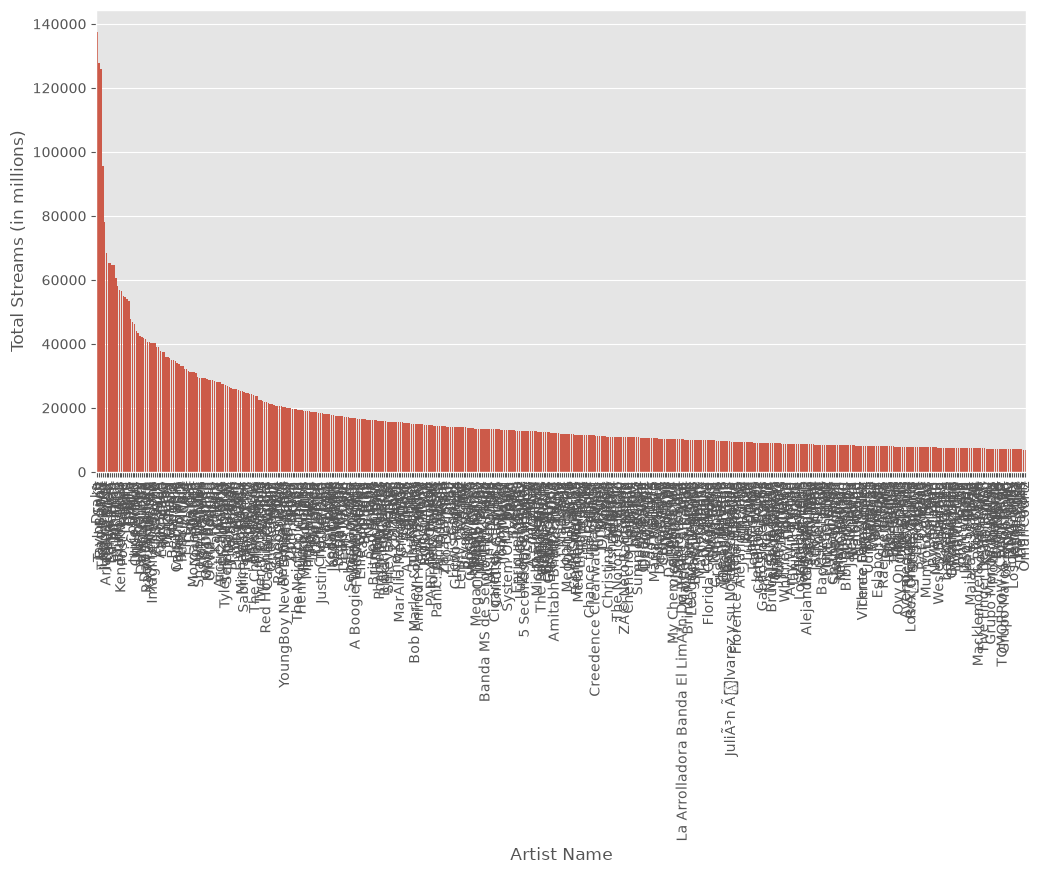

In [89]:
# 1 Total Streams
plt.figure(figsize=(12,6))
sns.barplot(
data=df,
x="Artist Name",
y="Total Streams (in millions)"
)
plt.xticks(rotation=90)
plt.show()

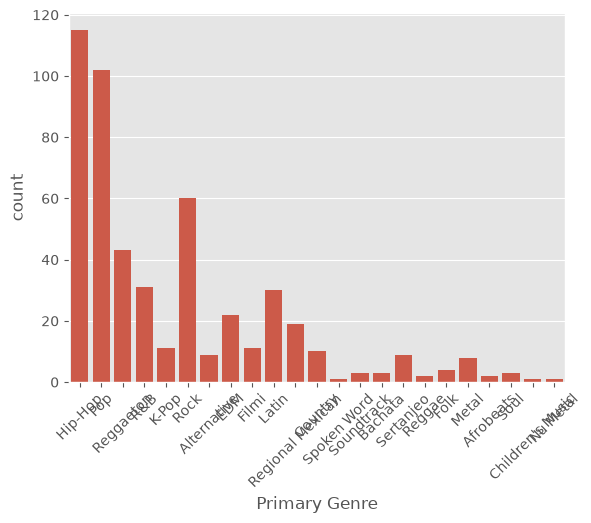

In [90]:
# 2 Genre Distribution
sns.countplot(
data=df,
x="Primary Genre"
)
plt.xticks(rotation=45)
plt.show()

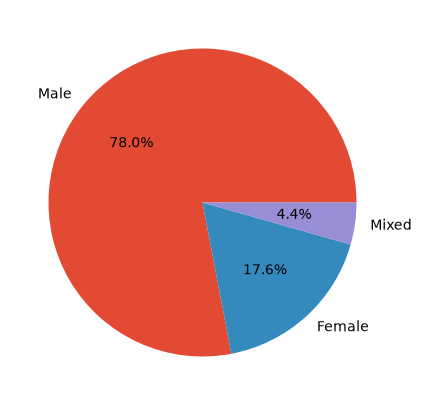

In [91]:
# 3 Gender Distribution
plt.figure(figsize=(5,5))
df["Sex"].value_counts().plot(
kind="pie",
autopct="%1.1f%%"
)
plt.ylabel("")
plt.show()

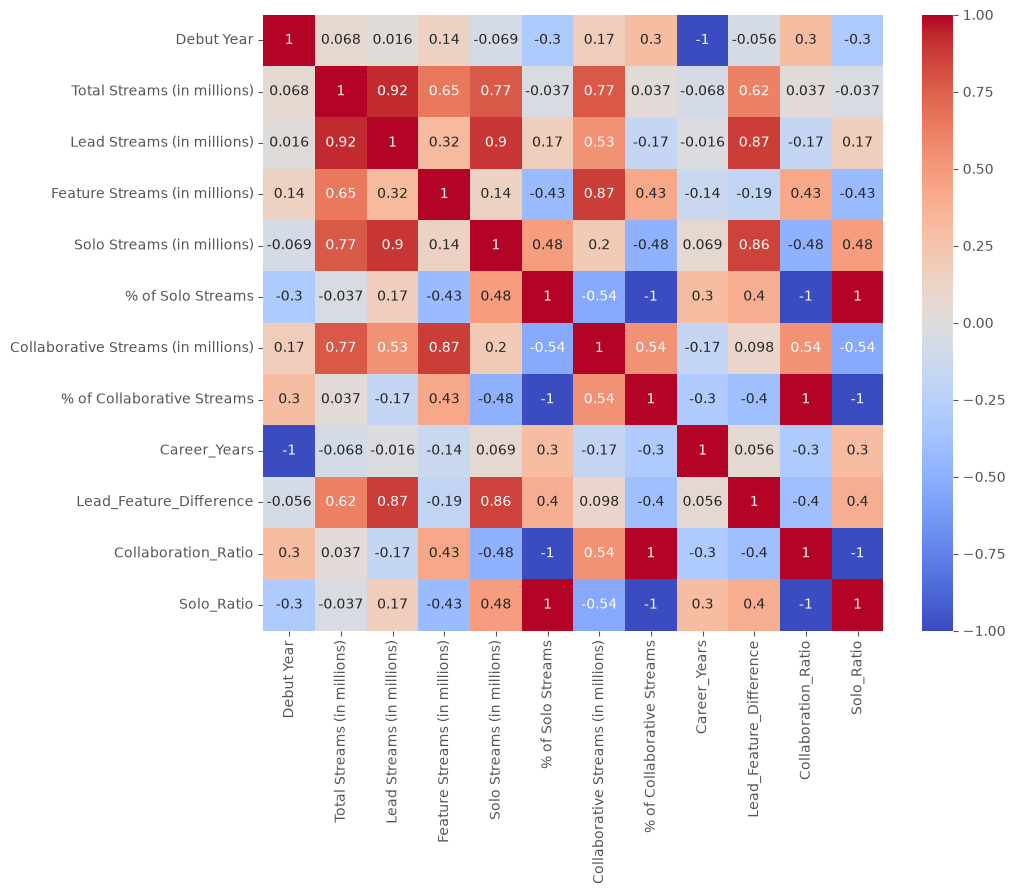

In [92]:
# 4 Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(
numeric_df.corr(),
annot=True,
cmap="coolwarm"
)
plt.show()

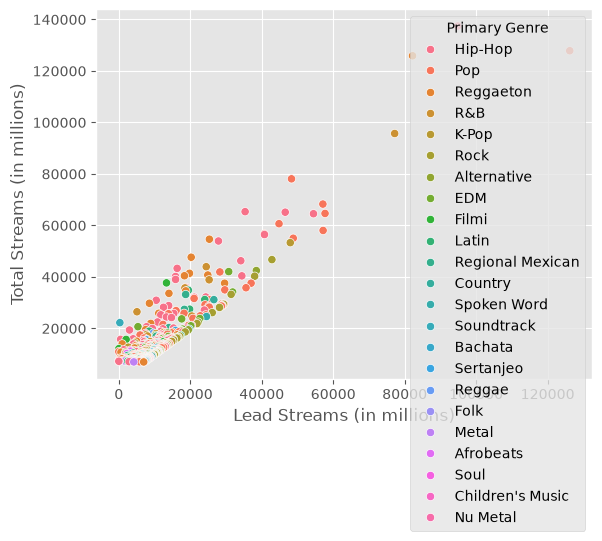

In [93]:
# 5 Scatter Plot
sns.scatterplot(
data=df,
x="Lead Streams (in millions)",
y="Total Streams (in millions)",
hue="Primary Genre"
)
plt.show()

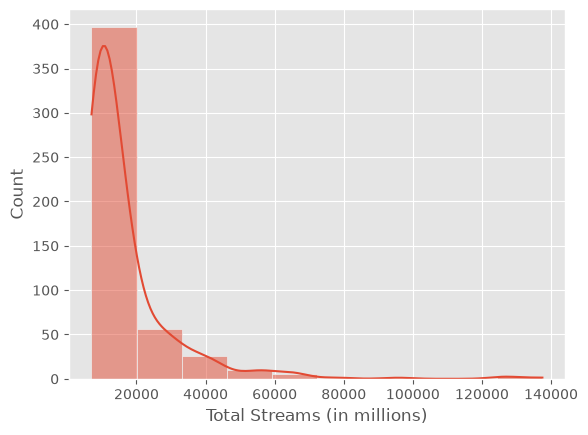

In [94]:
# 6 Histogram
sns.histplot(
df["Total Streams (in millions)"],
bins=10,
kde=True
)
plt.show()

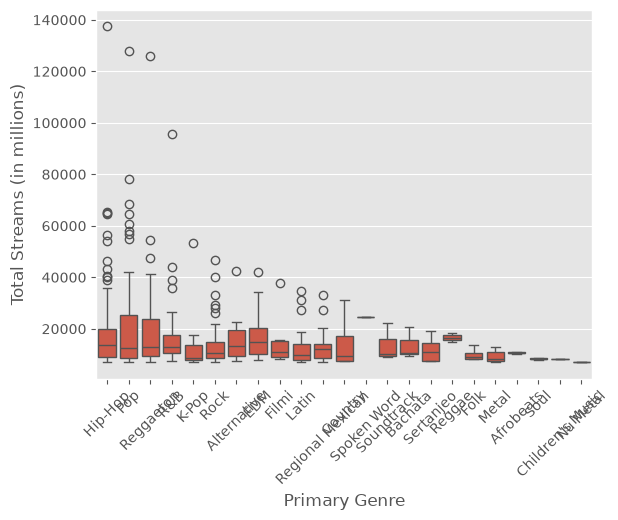

In [95]:
# 7 Box Plot
sns.boxplot(
data=df,
x="Primary Genre",
y="Total Streams (in millions)"
)
plt.xticks(rotation=45)
plt.show()

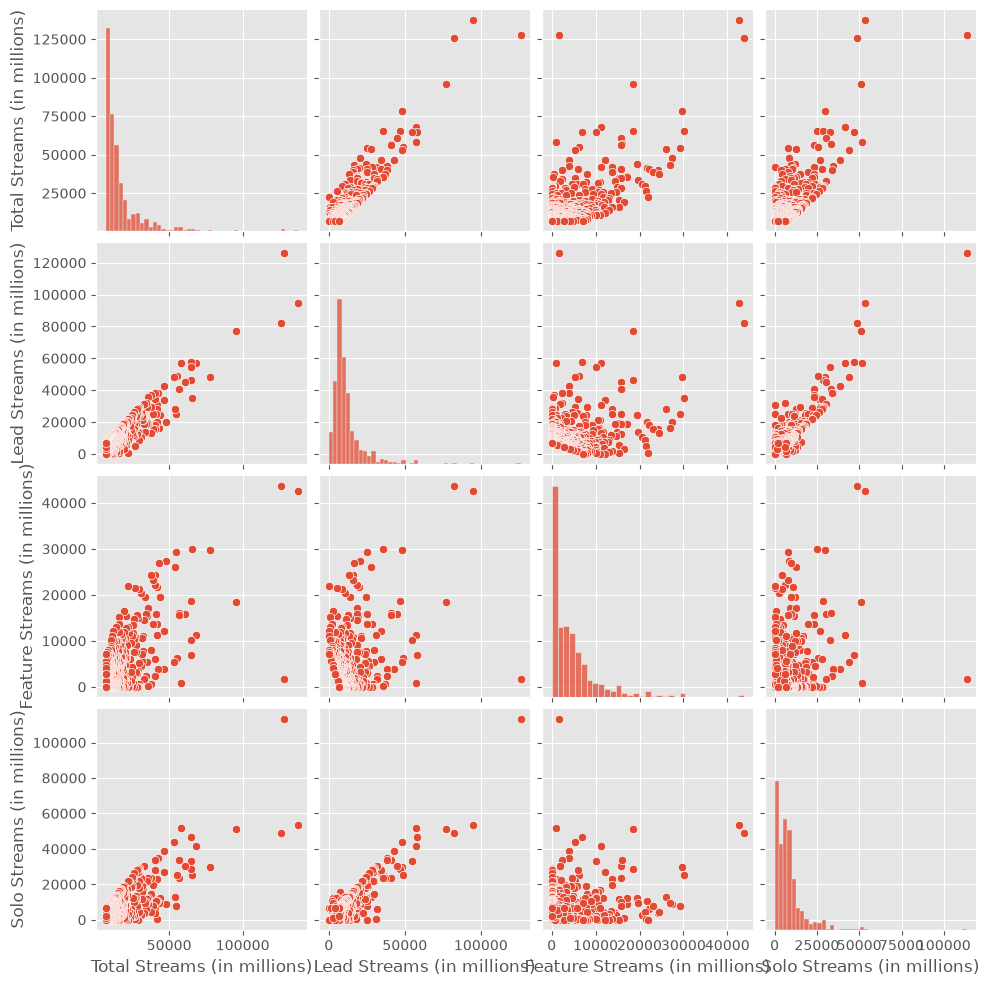

In [96]:
# 8 Pair Plot
sns.pairplot(
df[[
"Total Streams (in millions)",
"Lead Streams (in millions)",
"Feature Streams (in millions)",
"Solo Streams (in millions)"
]]
)
plt.show()

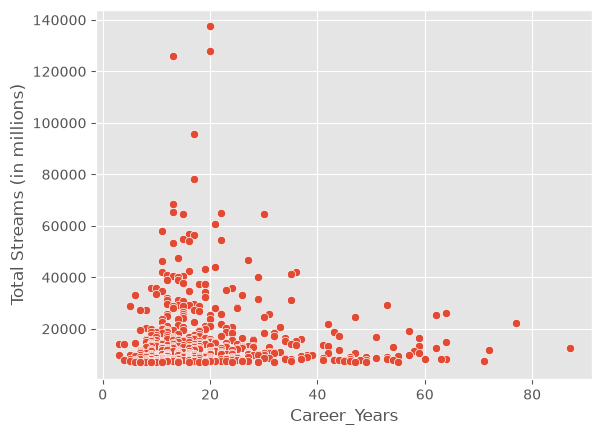

In [97]:
# 9 Career Years vs Streams
sns.scatterplot(
data=df,
x="Career_Years",
y="Total Streams (in millions)"
)
plt.show()

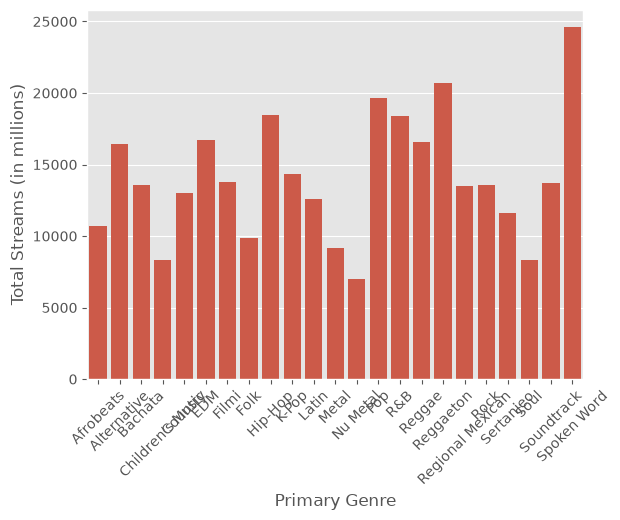

In [98]:
# 10 Genre-wise Average Streams
genre = df.groupby(
"Primary Genre"
)["Total Streams (in millions)"].mean().reset_index()
sns.barplot(
data=genre,
x="Primary Genre",
y="Total Streams (in millions)"
)
plt.xticks(rotation=45)
plt.show()

## Outlier Analysis

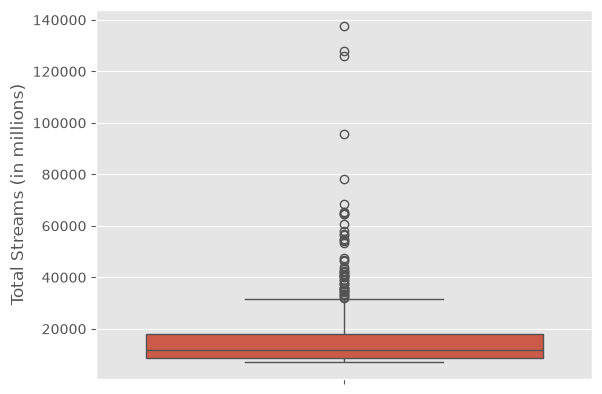

In [99]:
sns.boxplot(data=df, y="Total Streams (in millions)")
plt.show()

## Correlation Analysis

In [100]:
corr = df.corr(numeric_only=True)
corr

,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams,Career_Years,Lead_Feature_Difference,Collaboration_Ratio,Solo_Ratio
Debut Year,1.000000,0.068115,0.015666,0.138749,-0.068680,-0.298238,0.173707,0.298238,-1.000000,-0.055937,0.298238,-0.298238
Total Streams (in millions),0.068115,1.000000,0.924854,0.653678,0.772490,-0.037487,0.773762,0.037487,-0.068115,0.616974,0.037487,-0.037487
Lead Streams (in millions),0.015666,0.924854,1.000000,0.316741,0.898117,0.167773,0.532390,-0.167773,-0.015666,0.869917,-0.167773,0.167773
Feature Streams (in millions),0.138749,0.653678,0.316741,1.000000,0.139528,-0.427176,0.870331,0.427176,-0.138749,-0.192265,0.427176,-0.427176
Solo Streams (in millions),-0.068680,0.772490,0.898117,0.139528,1.000000,0.479296,0.195449,-0.479296,0.068680,0.856653,-0.479296,0.479296
% of Solo Streams,-0.298238,-0.037487,0.167773,-0.427176,0.479296,1.000000,-0.536020,-1.000000,0.298238,0.395699,-1.000000,1.000000
Collaborative Streams (in millions),0.173707,0.773762,0.532390,0.870331,0.195449,-0.536020,1.000000,0.536020,-0.173707,0.098272,0.536020,-0.536020
% of Collaborative Streams,0.298238,0.037487,-0.167773,0.427176,-0.479296,-1.000000,0.536020,1.000000,-0.298238,-0.395699,1.000000,-1.000000
Career_Years,-1.000000,-0.068115,-0.015666,-0.138749,0.068680,0.298238,-0.173707,-0.298238,1.000000,0.055937,-0.298238,0.298238
Lead_Feature_Difference,-0.055937,0.616974,0.869917,-0.192265,0.856653,0.395699,0.098272,-0.395699,0.055937,1.000000,-0.395699,0.395699


## Skills Demonstrated
- Data Cleaning with Pandas
- Exploratory Data Analysis (EDA)
- NumPy Statistical Analysis
- Data Aggregation (groupby, value_counts)
- Feature Engineering
- Data Visualization with Matplotlib and Seaborn
- Correlation Analysis
- Business Insight Generation
- README Documentation
- Jupyter Notebook Workflow

## Insights 

Example insights based on the provided sample:

- Drake has the highest total streams among the listed artists.
- Taylor Swift records the highest percentage of solo streams (about 89%), indicating strong solo performance.
- Hip-Hop and Pop are the dominant genres in the dataset.
- Most artists originate from the United States and Canada.
- English is the primary language for the majority of artists.
- Some artists, such as Drake and Justin Bieber, generate more than 60% of their streams through collaborations.
- There is a strong positive relationship between lead streams and total streams.
- Artists with longer careers do not always have the highest total streams, suggesting popularity depends on multiple factors.

## Conclusion

The analysis shows that artist popularity is influenced by multiple factors, including genre, collaborations, language, and career longevity. Collaboration contributes significantly to streaming success for many artists, while others achieve high performance primarily through solo releases.